In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mlt
df = pd.read_csv('/content/HDFCBANK.NS_stock_data.csv')

In [ ]:
df

,Unnamed: 0,open,high,low,close,adjclose,volume,ticker
0,1996-01-01,3.030000,3.030000,2.925000,2.980000,2.362861,350000.0,HDFCBANK.NS
1,1996-01-02,2.980000,3.025000,2.950000,2.975000,2.358896,412000.0,HDFCBANK.NS
2,1996-01-03,2.975000,2.995000,2.950000,2.985000,2.366825,284000.0,HDFCBANK.NS
3,1996-01-04,2.985000,2.980000,2.940000,2.965000,2.350967,282000.0,HDFCBANK.NS
4,1996-01-05,2.965000,2.980000,2.950000,2.960000,2.347002,189000.0,HDFCBANK.NS
...,...,...,...,...,...,...,...,...
7119,2024-04-23,1526.300049,1526.500000,1503.250000,1507.599976,1507.599976,13413530.0,HDFCBANK.NS
7120,2024-04-24,1515.000000,1521.750000,1509.050049,1511.699951,1511.699951,11220790.0,HDFCBANK.NS
7121,2024-04-25,1506.250000,1519.699951,1506.250000,1510.750000,1510.750000,17722602.0,HDFCBANK.NS
7122,2024-04-26,1519.800049,1528.000000,1505.550049,1509.800049,1509.800049,12427347.0,HDFCBANK.NS


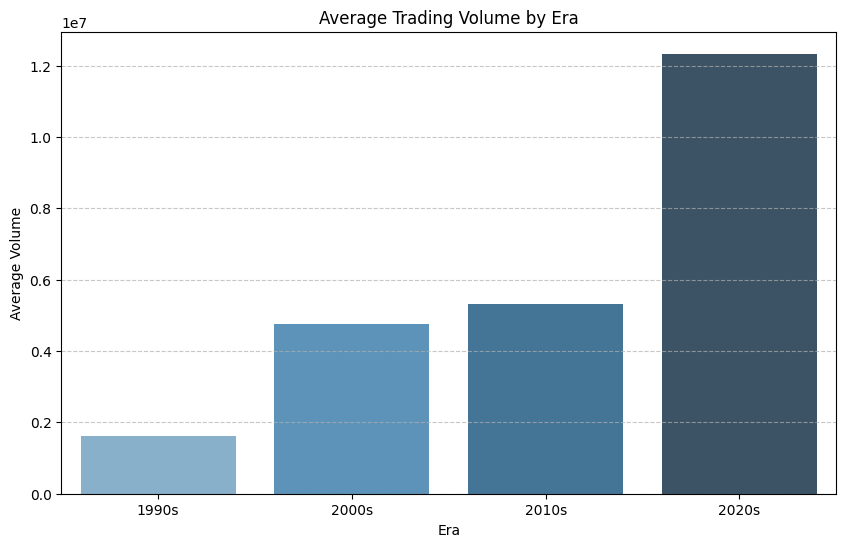

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(10, 6))
sns.barplot(x='Era', y='volume', data=avg_volume_by_era, palette='Blues_d', hue='Era', legend=False)
plt.title('Average Trading Volume by Era')
plt.xlabel('Era')
plt.ylabel('Average Volume')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#The bar chart above displays the average daily trading volume of HDFCBANK.NS stock across different decades.

/tmp/ipykernel_5755/1163070818.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Year', y='Yearly Return (%)', data=yearly_returns_df, palette=['lightgreen'], legend=False)
/tmp/ipykernel_5755/1163070818.py:6: UserWarning: 
The palette list has fewer values (1) than needed (29) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x='Year', y='Yearly Return (%)', data=yearly_returns_df, palette=['lightgreen'], legend=False)


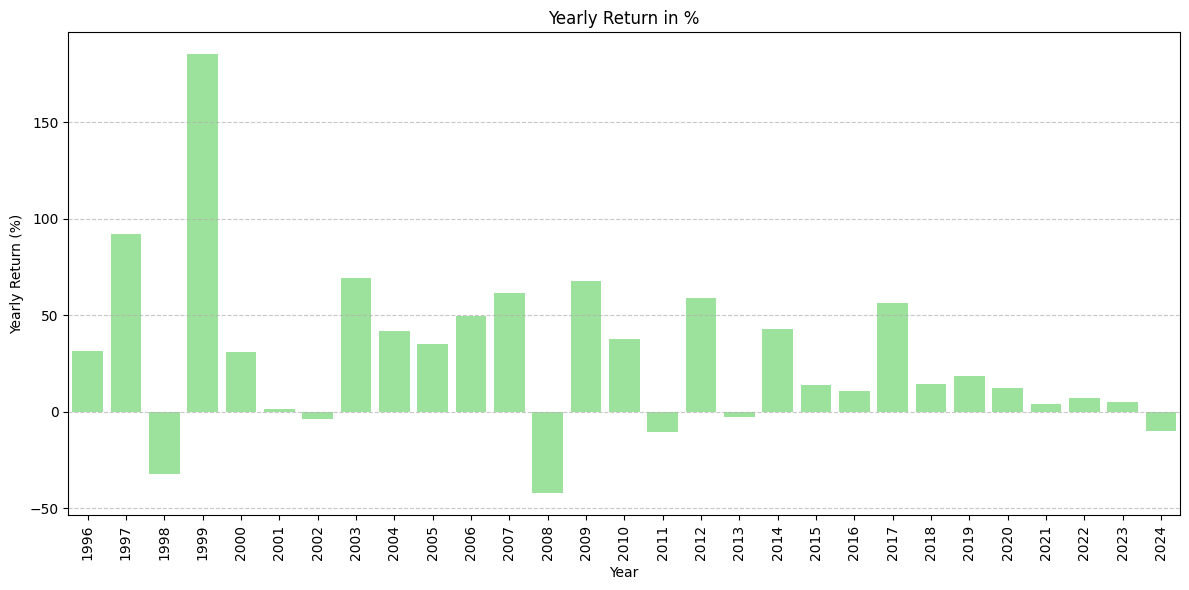

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the bar chart for yearly returns
fig = plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Yearly Return (%)', data=yearly_returns_df, palette=['lightgreen'], legend=False)
plt.title('Yearly Return in %')
plt.xlabel('Year')
plt.ylabel('Yearly Return (%)')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The bar chart above displays the yearly percentage returns for HDFCBANK.NS stock. We can observe significant fluctuations over the years, with both periods of strong positive returns and negative returns. The highest return appears to be around 1999, while some years show notable drops in value.

In [ ]:
# Ensure 'Date' column is datetime and 'Era' column exists.
# If these columns were not properly set up in previous steps, this code might need adjustment.
# For now, we assume 'df' has 'Date' (as datetime) and 'Era' columns populated correctly.

# Calculate the average closing price by Era
avg_price_by_era = df.groupby('Era')['close'].mean().reset_index()

# Ensure the 'Era' column is ordered for consistent plotting
era_order = ['1990s', '2000s', '2010s', '2020s']
avg_price_by_era['Era'] = pd.Categorical(avg_price_by_era['Era'], categories=era_order, ordered=True)
avg_price_by_era = avg_price_by_era.sort_values('Era')

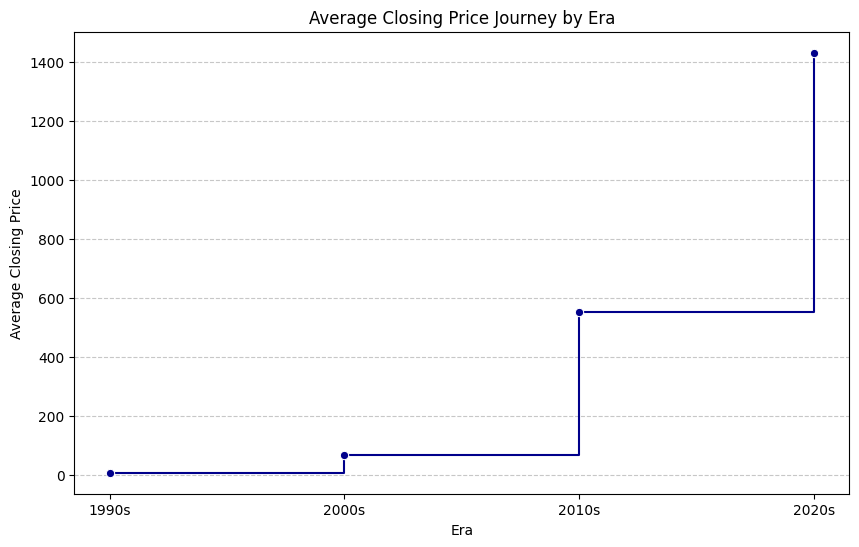

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(10, 6))
sns.lineplot(x='Era', y='close', data=avg_price_by_era, marker='o', drawstyle='steps-post', color='darkblue')
plt.title('Average Closing Price Journey by Era')
plt.xlabel('Era')
plt.ylabel('Average Closing Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The step line chart above illustrates the journey of the average closing price of HDFCBANK.NS stock across different eras. This visualization clearly shows a progressive increase in the average stock price from the 1990s to the 2020s, indicating a strong long-term growth trend for the stock. The 'steps' emphasize the distinct average price level for each decade before transitioning to the next.

In [ ]:
# Calculate daily percentage returns
df['daily_return'] = df['close'].pct_change() * 100

# Drop the first row which will have NaN for daily_return
df_returns = df.dropna(subset=['daily_return'])

/tmp/ipykernel_5755/26064931.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['daily_return'] = df['close'].pct_change() * 100


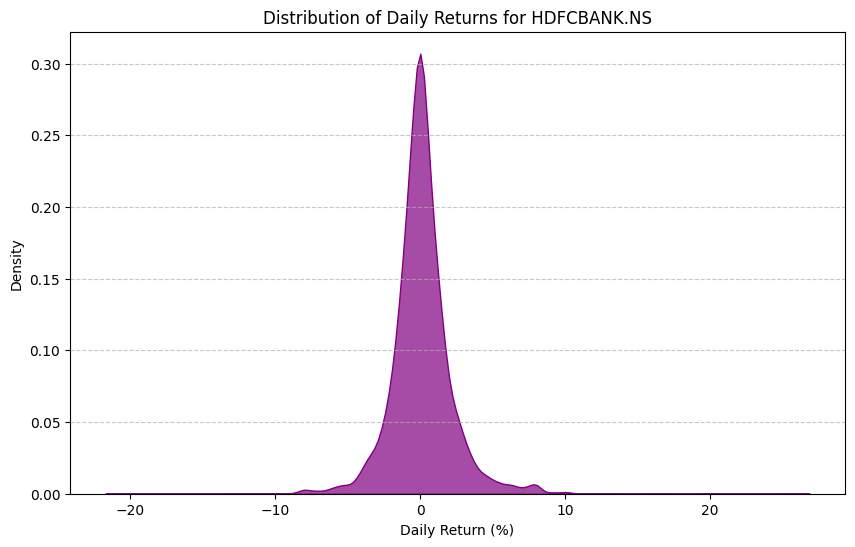

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(10, 6))
sns.kdeplot(df_returns['daily_return'], fill=True, color='purple', alpha=0.7)
plt.title('Distribution of Daily Returns for HDFCBANK.NS')
plt.xlabel('Daily Return (%)')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The density plot above visualizes the distribution of daily percentage returns for HDFCBANK.NS stock. The plot is centered around zero, indicating that on most days, the stock's price change is relatively small. The peak around zero signifies that small positive or negative daily returns are the most frequent. The tails on both sides, though less dense, represent days with larger positive or negative price movements, suggesting the presence of both significant gains and losses over the stock's history.

In [ ]:
# Ensure 'Unnamed: 0' (Date column) is converted to datetime and set as index if not already
if 'Unnamed: 0' in df.columns:
    df['Date'] = pd.to_datetime(df['Unnamed: 0'])
    df = df.drop(columns=['Unnamed: 0'])
else:
    df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year

# Calculate daily returns if not already done
# We already have df['daily_return'] from a previous step, but let's ensure it's up-to-date
df['daily_return'] = df['close'].pct_change() * 100

# Calculate yearly risk (standard deviation of daily returns)
yearly_risk = df.groupby('Year')['daily_return'].std().reset_index()

# Rename the column for clarity
yearly_risk = yearly_risk.rename(columns={'daily_return': 'Yearly Risk (%)'})

# Display the calculated yearly risk
display(yearly_risk.head())

/tmp/ipykernel_5755/3678135574.py:12: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['daily_return'] = df['close'].pct_change() * 100


,Year,Yearly Risk (%)
0,1996,2.478691
1,1997,2.460225
2,1998,2.873354
3,1999,3.562612
4,2000,3.299524


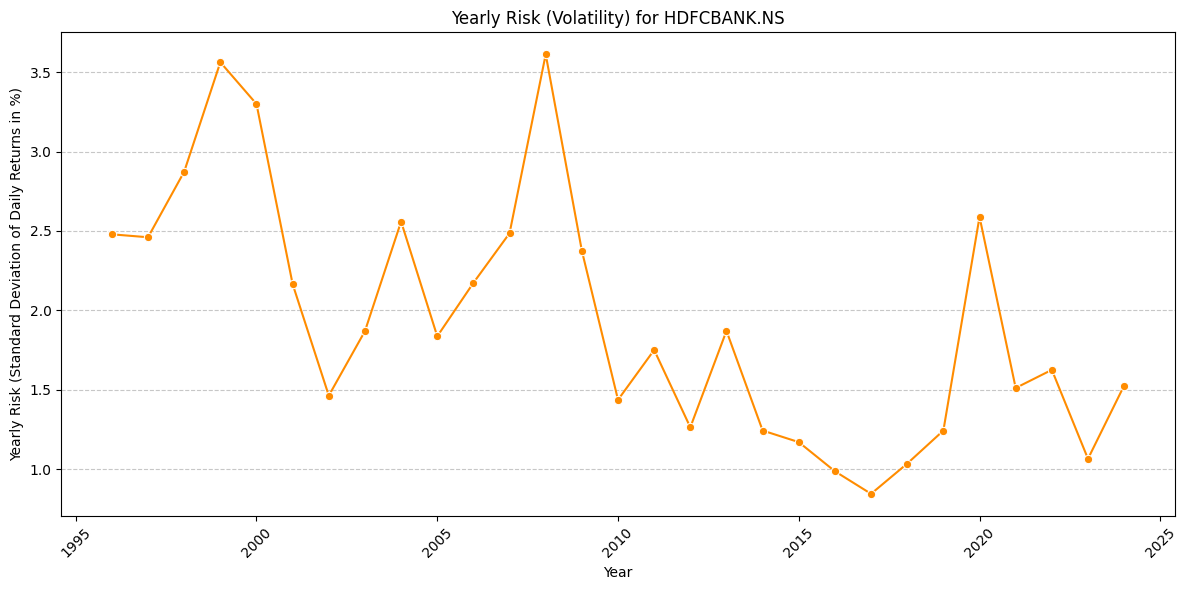

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Yearly Risk (%)', data=yearly_risk, marker='o', color='darkorange')
plt.title('Yearly Risk (Volatility) for HDFCBANK.NS')
plt.xlabel('Year')
plt.ylabel('Yearly Risk (Standard Deviation of Daily Returns in %)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The line chart above illustrates the yearly risk, represented by the standard deviation of daily returns, for HDFCBANK.NS stock. This plot helps in understanding the historical volatility of the stock. Higher values indicate periods of greater price fluctuations, while lower values suggest more stable periods. We can observe how the stock's risk profile has evolved over the years, with certain periods showing higher or lower volatility.

In [ ]:
# Install mplfinance library if not already installed
!pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 5.4 MB/s eta 0:00:00


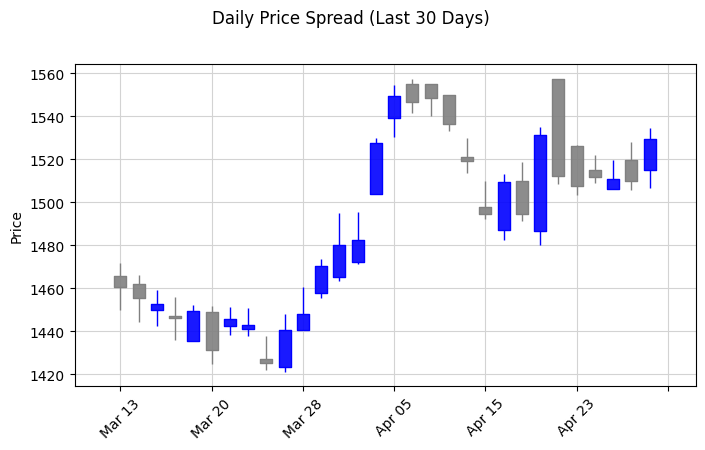

In [ ]:
import mplfinance as mpf

# Ensure 'Date' column is in datetime format and set as index
# Assuming 'Date' column is already created and parsed as datetime from previous steps.
# If 'Date' was dropped, re-create it from the original 'Unnamed: 0' if it still exists.
if 'Unnamed: 0' in df.columns and df['Unnamed: 0'].dtype == 'object': # Check if Unnamed: 0 exists and is not yet processed
    df['Date'] = pd.to_datetime(df['Unnamed: 0'])
    df = df.drop(columns=['Unnamed: 0'])
elif 'Date' not in df.columns: # If 'Date' column was dropped but 'Unnamed: 0' is gone
    # This scenario should not happen if previous steps were executed sequentially
    # For robustness, we can try to infer date from other columns or original CSV
    # For now, we assume 'Date' exists or can be created from 'Unnamed: 0' as a fallback.
    # If 'Date' column was already processed and used, this block won't re-execute.
    print("Warning: 'Date' column not found, attempting to re-create from 'Unnamed: 0' if available.")
    if 'Unnamed: 0' in df.columns:
        df['Date'] = pd.to_datetime(df['Unnamed: 0'])
        df = df.drop(columns=['Unnamed: 0'])

# Set the 'Date' column as the index for mplfinance
df_candlestick = df.set_index('Date')

# Drop any rows with NaN values in the OHLC columns, which might arise from date conversion issues
df_candlestick = df_candlestick.dropna(subset=['open', 'high', 'low', 'close'])

# Select the relevant columns for the candlestick chart
ohcl_data = df_candlestick[['open', 'high', 'low', 'close']]

# Define custom colors (blue for up, gray for down)
my_colors = mpf.make_marketcolors(up='blue', down='gray', inherit=True)
my_style = mpf.make_mpf_style(marketcolors=my_colors, gridcolor='lightgray')

# Plotting the candlestick chart for a recent period (e.g., last 30 days for clarity)
# Adjust `num_days` as needed for different views
num_days = 30
if len(ohcl_data) > num_days:
    plot_data = ohcl_data.iloc[-num_days:]
else:
    plot_data = ohcl_data

fig, axlist = mpf.plot(plot_data,
                   type='candle',
                   style=my_style,
                   title=f'Daily Price Spread (Last {len(plot_data)} Days)',
                   ylabel='Price',
                   figratio=(15,8),
                   figscale=0.8,
                   returnfig=True)
plt.show()

The candlestick chart above visualizes the daily price spread (open, high, low, close) for HDFCBANK.NS stock. Each candlestick represents one trading day:

*   **Blue candles** indicate days where the closing price was higher than the opening price (an 'up' day).
*   **Gray candles** indicate days where the closing price was lower than the opening price (a 'down' day).
*   The **body** of the candle shows the range between the opening and closing prices.
*   The **wicks (or shadows)** extending from the top and bottom of the body represent the daily high and low prices, respectively.

This chart helps to quickly understand the daily price movements, volatility, and sentiment. Long blue bodies suggest strong buying pressure, while long gray bodies indicate strong selling pressure. Short bodies with long wicks might suggest indecision or significant price reversals within the day.

In [ ]:
# Determine day type: Bullish (close > open), Bearish (close < open), Neutral (close == open)
def get_day_type(row):
    if row['close'] > row['open']:
        return 'Bullish'
    elif row['close'] < row['open']:
        return 'Bearish'
    else:
        return 'Neutral'

df['day_type'] = df.apply(get_day_type, axis=1)

# Count the occurrences of each day type
day_type_counts = df['day_type'].value_counts().reset_index()
day_type_counts.columns = ['Day Type', 'Count']

# Display the counts
display(day_type_counts)

,Day Type,Count
0,Bearish,3588
1,Bullish,3377
2,Neutral,159


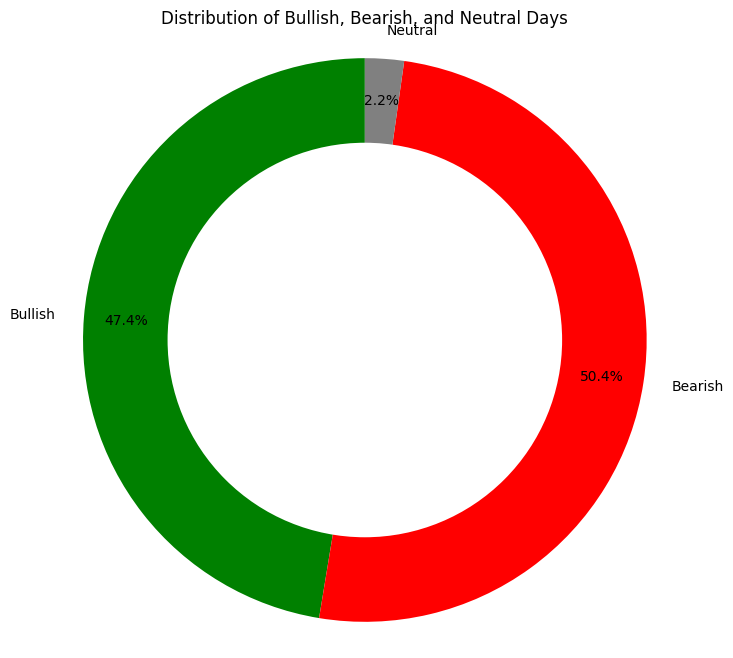

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define custom colors
colors = {'Bullish': 'green', 'Bearish': 'red', 'Neutral': 'grey'}

# Ensure the order of day types for consistent coloring in the plot
pie_data = day_type_counts.set_index('Day Type').loc[['Bullish', 'Bearish', 'Neutral']].fillna(0)

fig = plt.figure(figsize=(8, 8)) # Set a good figure size
plt.pie(pie_data['Count'],
        labels=pie_data.index,
        colors=[colors[label] for label in pie_data.index],
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.85) # pctdistance moves the percentage labels closer to the center

# Draw a white circle in the center to create a donut chart
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

plt.title('Distribution of Bullish, Bearish, and Neutral Days')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

The donut chart above illustrates the distribution of bullish, bearish, and neutral trading days for HDFCBANK.NS stock.

*   **Green slices** represent **bullish days** (closing price higher than opening price).
*   **Red slices** represent **bearish days** (closing price lower than opening price).
*   **Grey slices** represent **neutral days** (closing price equal to opening price).

This visualization provides a quick overview of the overall market sentiment for the stock over its history. A higher percentage of bullish days indicates a generally upward trend in the stock's price movements, while a higher percentage of bearish days suggests a downward trend. Neutral days indicate periods of minimal price change.

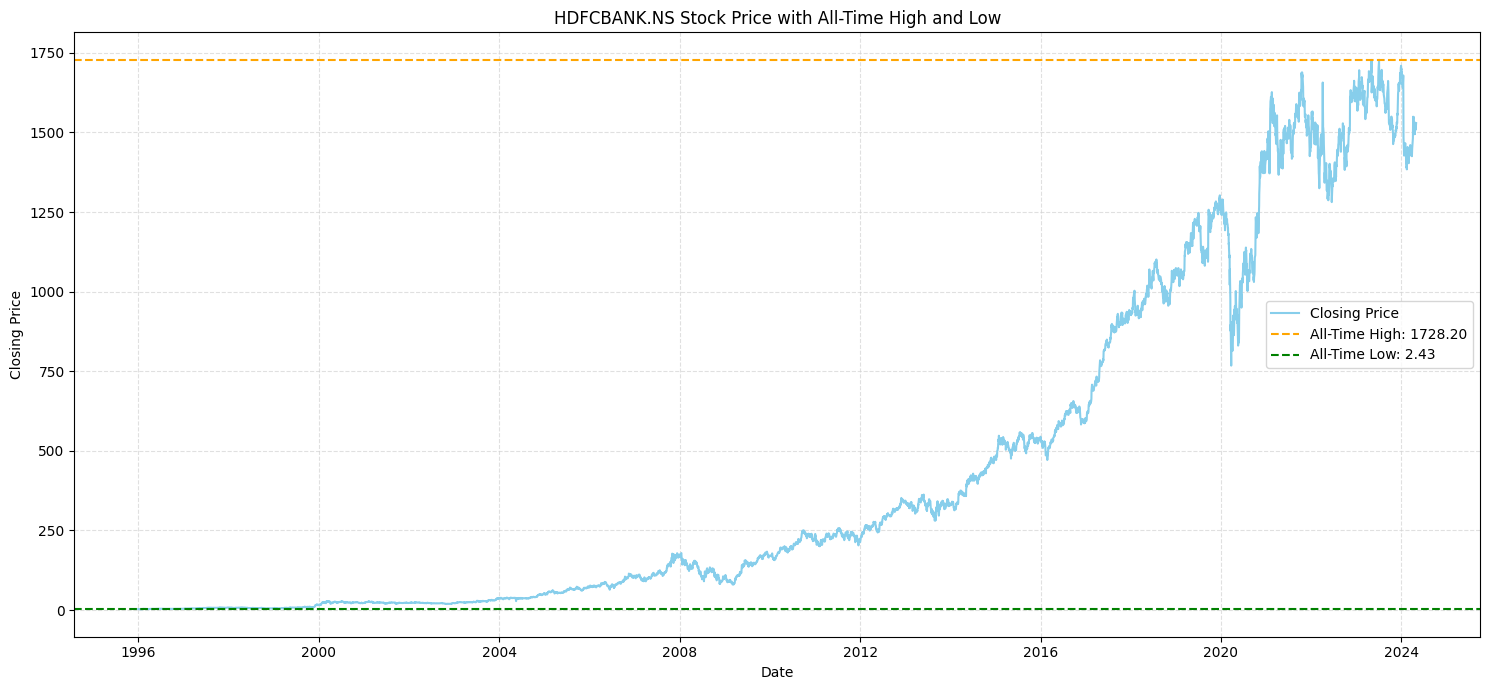

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Date' column is in datetime format for plotting
# Assuming 'Date' column is already available and parsed from previous steps.
# If not, recreate it from 'Unnamed: 0' as a fallback, similar to candlestick chart.
if 'Unnamed: 0' in df.columns and df['Unnamed: 0'].dtype == 'object':
    df['Date'] = pd.to_datetime(df['Unnamed: 0'])
    df = df.drop(columns=['Unnamed: 0'])

# Calculate all-time high and low closing prices
all_time_high = df['close'].max()
all_time_low = df['close'].min()

# Create the plot
fig = plt.figure(figsize=(15, 7))
sns.lineplot(x=df['Date'], y=df['close'], data=df, color='skyblue', label='Closing Price')

# Plot all-time high and low as horizontal lines
plt.axhline(y=all_time_high, color='orange', linestyle='--', label=f'All-Time High: {all_time_high:.2f}')
plt.axhline(y=all_time_low, color='green', linestyle='--', label=f'All-Time Low: {all_time_low:.2f}')

plt.title('HDFCBANK.NS Stock Price with All-Time High and Low')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

The line chart above visualizes the closing price of HDFCBANK.NS stock over its entire history, with horizontal lines indicating the all-time high and all-time low closing prices.

*   The **blue line** represents the daily closing price fluctuations over the years.
*   The **orange dashed line** marks the **All-Time High closing price** of the stock, showing the peak value it has ever reached.
*   The **green dashed line** indicates the **All-Time Low closing price**, representing the lowest point the stock has traded at.

This chart provides a clear historical perspective on the stock's price range, illustrating its growth trajectory, periods of significant gains, and its absolute lowest valuation. It helps investors understand the extremes of the stock's performance and its long-term trend within these boundaries.

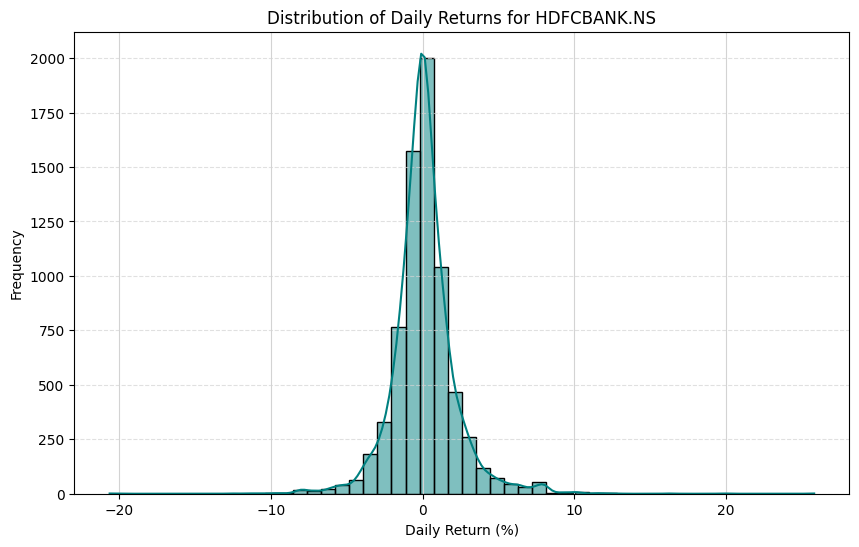

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'daily_return' column is available
# It should have been calculated in previous steps, but we can re-calculate if needed.
if 'daily_return' not in df.columns:
    df['daily_return'] = df['close'].pct_change() * 100

# Drop NaN values that result from pct_change()
df_returns_clean = df.dropna(subset=['daily_return'])

fig = plt.figure(figsize=(10, 6))
sns.histplot(df_returns_clean['daily_return'], bins=50, kde=True, color='teal')
plt.title('Distribution of Daily Returns for HDFCBANK.NS')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The histogram above illustrates the distribution of daily percentage returns for HDFCBANK.NS stock. The distribution appears centered around zero, indicating that most daily price changes are relatively small. The peak around zero signifies that days with minimal positive or negative returns are the most frequent.

The tails of the histogram, though less frequent, represent days with larger positive or negative price movements. The presence of these tails suggests that while the stock is generally stable, it does experience periods of significant gains and losses. The overall shape, resembling a bell curve, is common for financial asset returns, often showing higher kurtosis (fatter tails) than a normal distribution, implying more extreme events than would be predicted by pure randomness.

In [ ]:
# Ensure 'Date' column is in datetime format
# If 'Unnamed: 0' exists, use it to create 'Date' column
if 'Unnamed: 0' in df.columns and df['Unnamed: 0'].dtype == 'object':
    df['Date'] = pd.to_datetime(df['Unnamed: 0'])
    df = df.drop(columns=['Unnamed: 0'])
elif 'Date' not in df.columns:
    # Fallback if 'Date' is missing and 'Unnamed: 0' is not available or already processed
    print("Warning: 'Date' column not found. Attempting to infer or regenerate.")
    # This part might need more robust logic depending on actual data state
    # For this task, assuming 'Date' exists or can be created as above
    pass # If 'Date' is already processed as index in df_candlestick, it might not be in df anymore as a column.
         # Re-load or reset index if necessary for df. In this context, df still has 'Date' column.

df['Month'] = df['Date'].dt.month

# Aggregate volume by month
monthly_volume = df.groupby('Month')['volume'].sum().reset_index()

# Map month numbers to names for better readability
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_volume['Month Name'] = monthly_volume['Month'].map(lambda x: month_names[x-1])

# Display the aggregated data
display(monthly_volume.head())

,Month,volume,Month Name
0,1,3.560619e+09,Jan
1,2,3.201841e+09,Feb
2,3,4.054514e+09,Mar
3,4,3.603740e+09,Apr
4,5,3.307045e+09,May


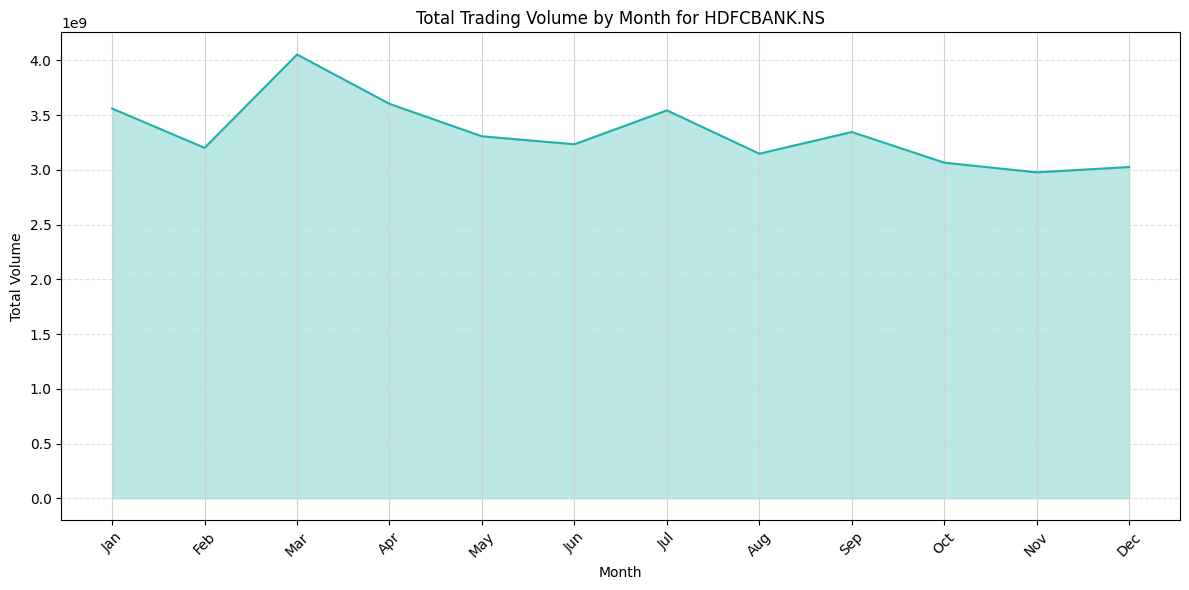

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(x='Month Name', y='volume', data=monthly_volume, color='lightseagreen', ax=ax)
ax.fill_between(monthly_volume['Month Name'], monthly_volume['volume'], color='lightseagreen', alpha=0.3)
plt.title('Total Trading Volume by Month for HDFCBANK.NS')
plt.xlabel('Month')
plt.ylabel('Total Volume')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The area chart above illustrates the total trading volume for HDFCBANK.NS stock across different months of the year. This visualization helps to identify potential seasonal patterns or periods of higher or lower trading activity. Peaks in the chart suggest months with increased investor interest or significant market events, while troughs indicate periods of relatively lower trading volume.